# Medical Triage Dataset — Exploration and Statistical Analysis

This notebook explores the medical triage assistant training datasets (synthetic symptoms datasets and split train/val/test pools). We analyze class distribution, text lengths, and characteristic clinical terms for EMERGENCY, URGENT, and ROUTINE classes.

## 1. Environment Setup & Data Loading

In [1]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

DATA_DIR = Path("../data")

In [1]:
def load_dataset(name):
    path = DATA_DIR / f"processed/{name}.jsonl"
    if not path.exists():
        path = DATA_DIR / f"synthetic/{name}_samples.jsonl"
    if not path.exists():
        print(f"Path not found: {path}")
        return []
    with open(path, "r") as f:
        return [json.loads(line) for line in f]

train_data = load_dataset("train")
val_data = load_dataset("val")
test_data = load_dataset("test")
print(f"Loaded {len(train_data)} train samples")
print(f"Loaded {len(val_data)} validation samples")
print(f"Loaded {len(test_data)} test samples")

## 2. Class Distribution (EMERGENCY vs URGENT vs ROUTINE)

In [1]:
train_counts = Counter(d["triage_level"] for d in train_data)
val_counts = Counter(d["triage_level"] for d in val_data)
test_counts = Counter(d["triage_level"] for d in test_data)

df_counts = pd.DataFrame({
    "Train": train_counts,
    "Val": val_counts,
    "Test": test_counts
}).fillna(0).astype(int)

print("Class Distribution across Splits:")
print(df_counts)

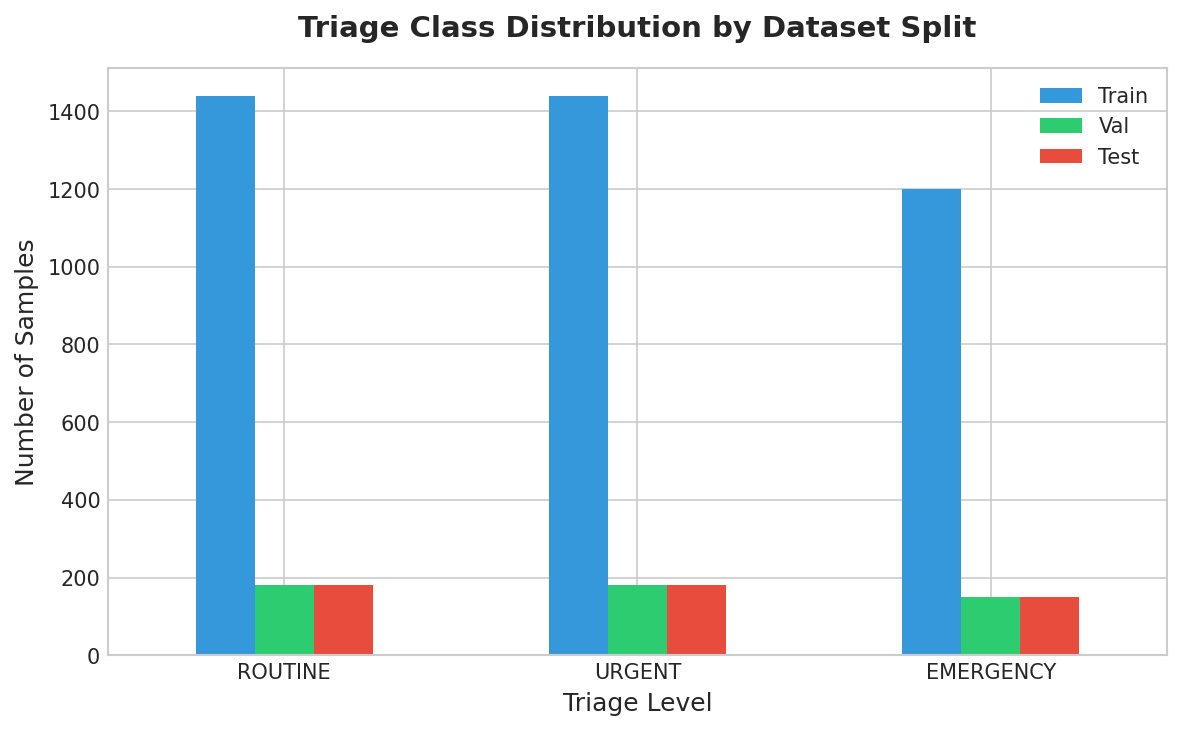

In [1]:
# Plot class distributions
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, ax = plt.subplots(figsize=(8, 5))
df_counts.plot(kind="bar", ax=ax, color=["#3498db", "#2ecc71", "#e74c3c"])
ax.set_title("Triage Class Distribution by Dataset Split", fontsize=14, fontweight="bold", pad=15)
ax.set_ylabel("Number of Samples", fontsize=12)
ax.set_xlabel("Triage Level", fontsize=12)
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

## 3. Text Length Distribution (Word Counts)

In [1]:
train_df = pd.DataFrame(train_data)
train_df["desc_words"] = train_df["symptom_description"].apply(lambda x: len(str(x).split()))
train_df["reasoning_words"] = train_df["raw_output"].apply(lambda x: len(str(x).split()) if pd.notnull(x) else 0)

print("Text Length Descriptive Statistics (in words):")
print(train_df[["desc_words", "reasoning_words"]].describe())

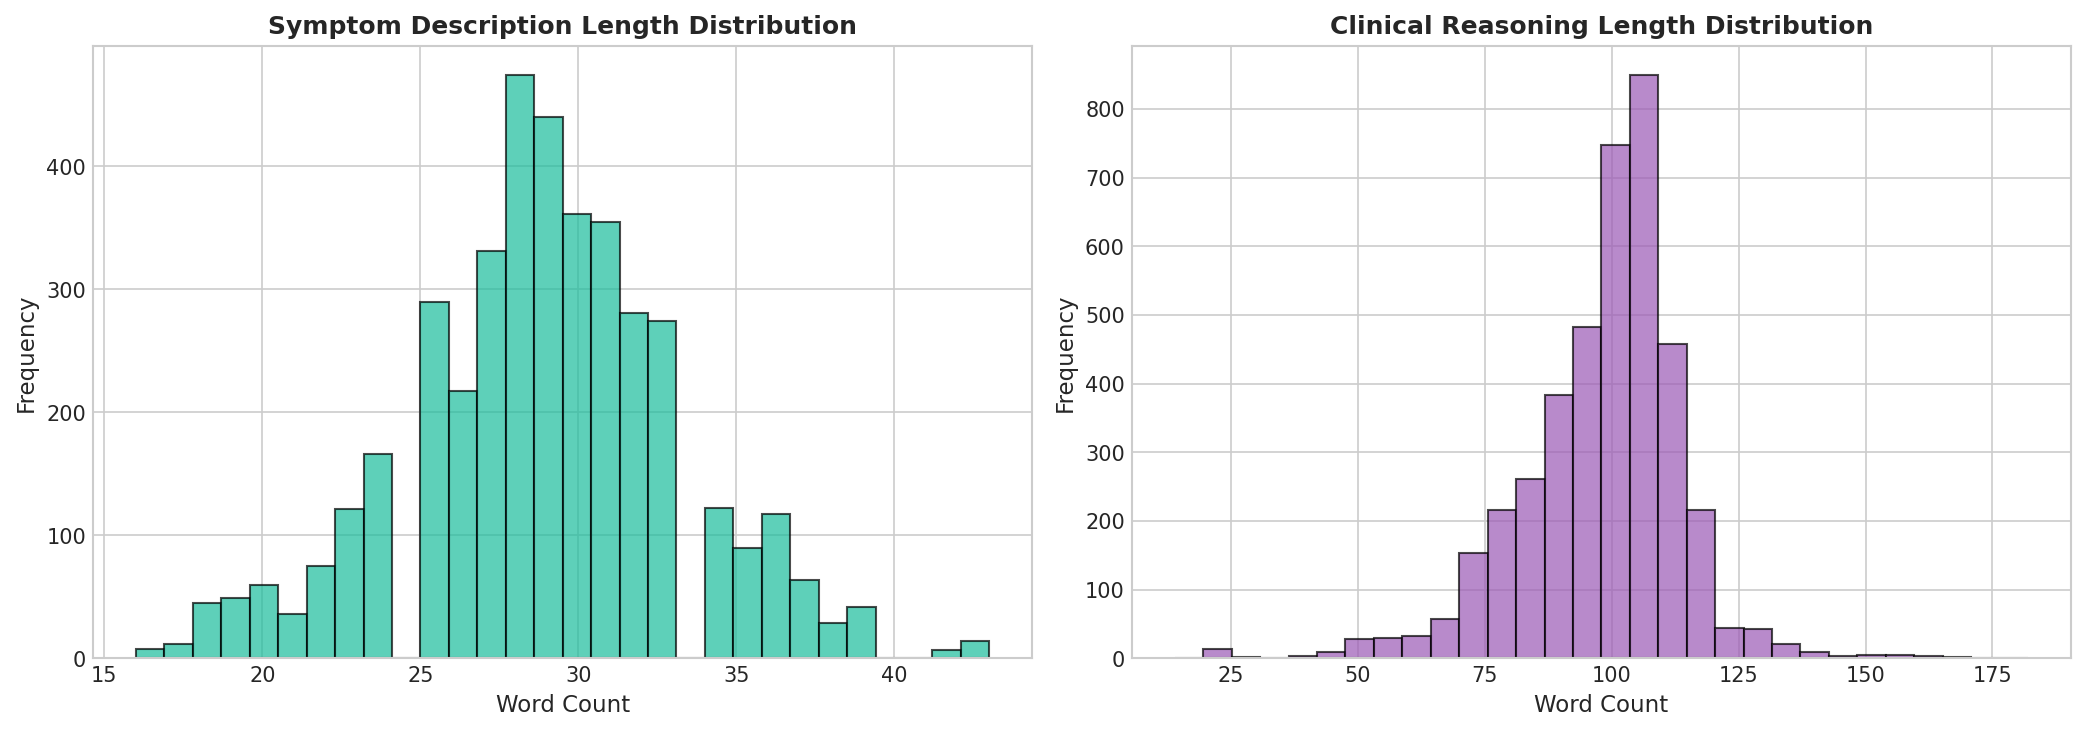

In [1]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Description length distribution
ax1.hist(train_df["desc_words"], bins=30, color="#1abc9c", edgecolor="black", alpha=0.7)
ax1.set_title("Symptom Description Length Distribution", fontsize=12, fontweight="bold")
ax1.set_xlabel("Word Count", fontsize=11)
ax1.set_ylabel("Frequency", fontsize=11)

# Reasoning length distribution
ax2.hist(train_df["reasoning_words"], bins=30, color="#9b59b6", edgecolor="black", alpha=0.7)
ax2.set_title("Clinical Reasoning Length Distribution", fontsize=12, fontweight="bold")
ax2.set_xlabel("Word Count", fontsize=11)
ax2.set_ylabel("Frequency", fontsize=11)

plt.tight_layout()
plt.show()

## 4. Word Frequency Analysis of Clinical Symptoms per Triage Level

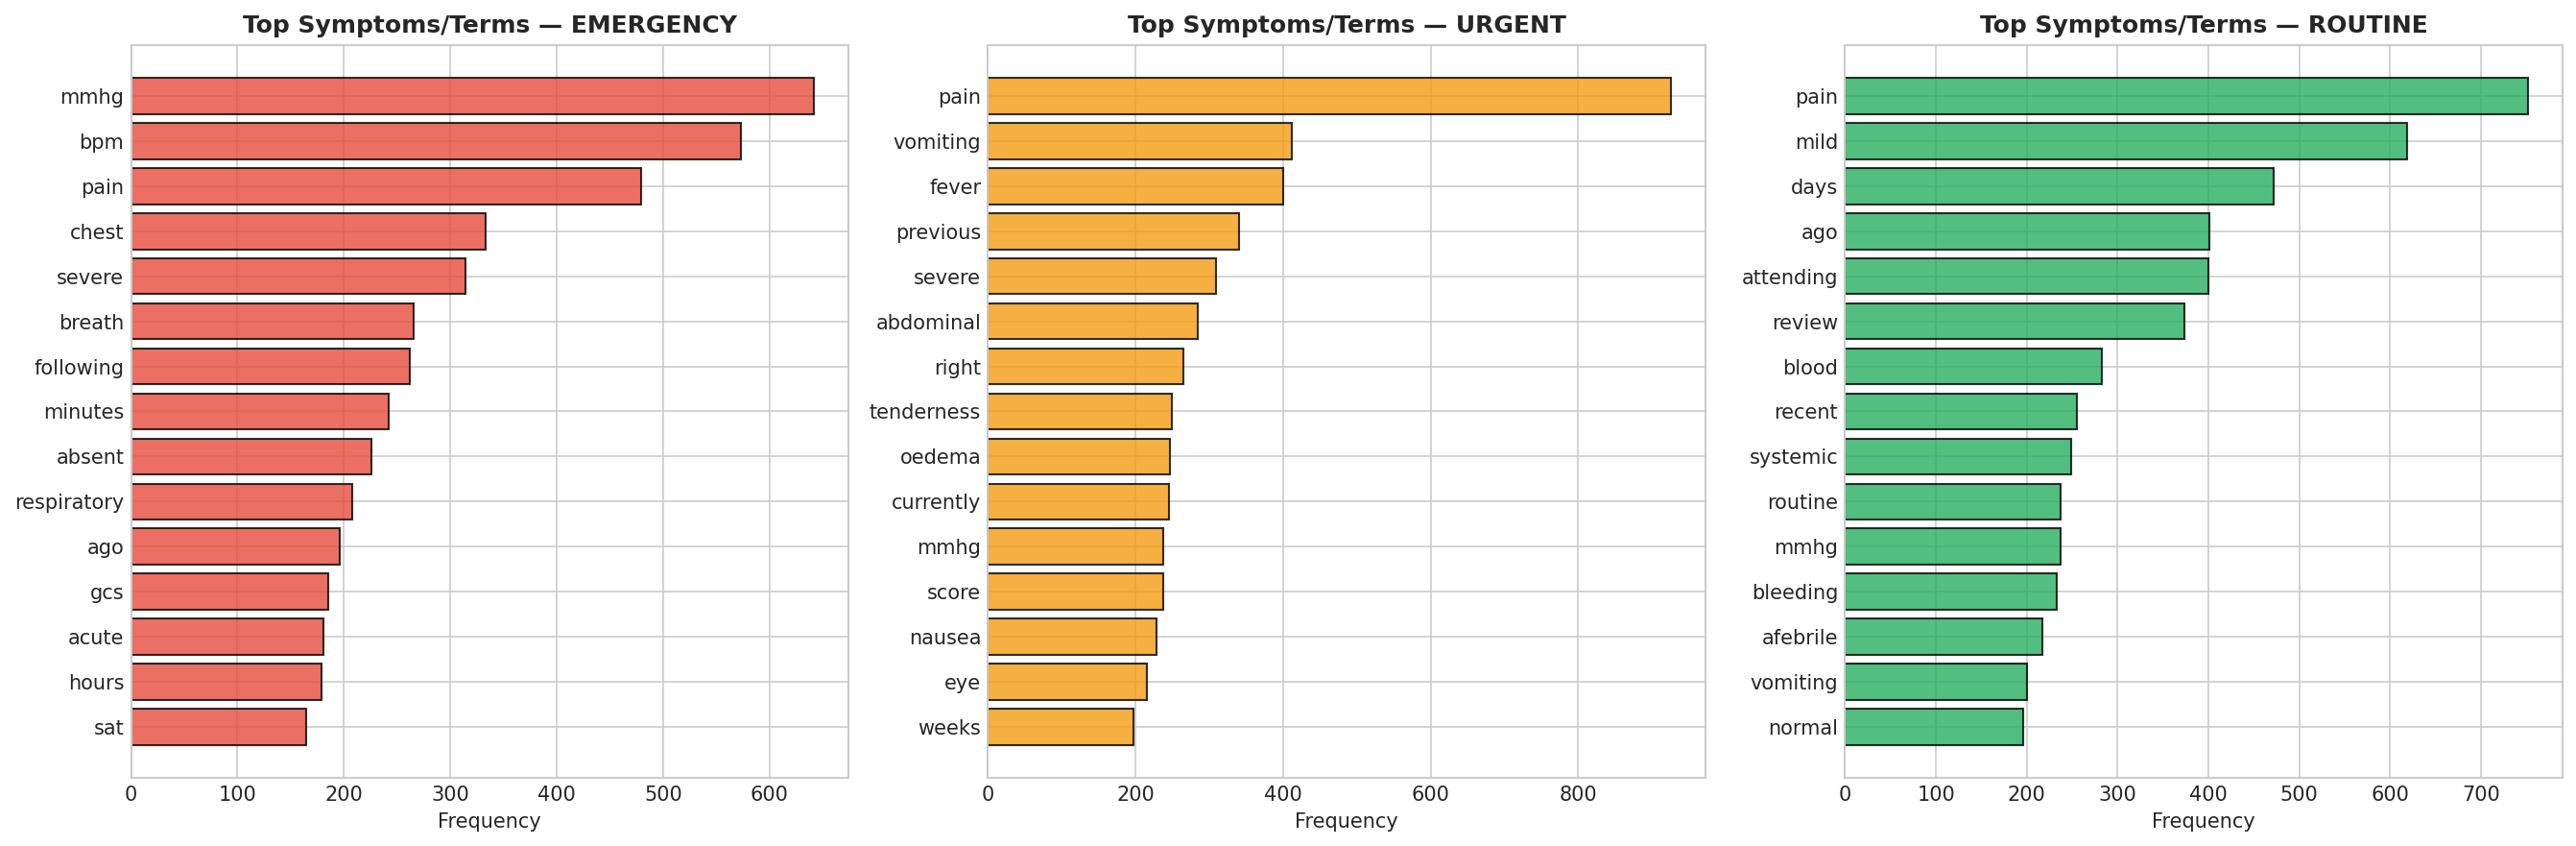

In [1]:
# Extract characteristic words per triage class (excluding common English stopwords)
stopwords = {"a", "an", "the", "and", "or", "but", "if", "then", "of", "to", "for", "in", "on", "with", "by", "at", "from", 
             "is", "was", "were", "are", "be", "been", "he", "she", "it", "they", "we", "i", "you", "his", "her", "their", 
             "our", "my", "your", "has", "have", "had", "no", "not", "any", "some", "every", "all", "this", "that", "these", 
             "those", "patient", "history", "presents", "presenting", "years", "old", "male", "female", "with", "symptoms", 
             "reported", "showed", "history", "duration", "prior", "known", "presented", "daily", "episodes", "onset", "sudden"}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
labels = ["EMERGENCY", "URGENT", "ROUTINE"]
colors_map = {"EMERGENCY": "#e74c3c", "URGENT": "#f39c12", "ROUTINE": "#27ae60"}

for i, label in enumerate(labels):
    subset = train_df[train_df["triage_level"] == label]
    all_words = []
    for text in subset["symptom_description"]:
        words = str(text).lower().replace(",", "").replace(".", "").replace(":", "").replace(";", "").split()
        all_words.extend([w for w in words if w not in stopwords and len(w) > 2])
    
    common = Counter(all_words).most_common(15)
    df_w = pd.DataFrame(common, columns=["Word", "Frequency"]).sort_values("Frequency", ascending=True)
    
    axes[i].barh(df_w["Word"], df_w["Frequency"], color=colors_map[label], edgecolor="black", alpha=0.8)
    axes[i].set_title(f"Top Symptoms/Terms — {label}", fontsize=12, fontweight="bold")
    axes[i].set_xlabel("Frequency")

plt.tight_layout()
plt.show()

## 5. Sample Visual Inspection

In [1]:
# Inspect the raw JSON layout of one dataset sample
sample = train_data[0]
print(f"TRIAGE CLASS: {sample['triage_level']}")
print(f"TEACHER CONFIDENCE: {sample.get('confidence', 'N/A')}\n")
print("PATIENT DESCRIPTION:")
print(sample['symptom_description'])
print("\nGENERATED RAW OUTPUT (CLINICAL REASONING CHAIN):")
print(sample.get('raw_output', 'N/A'))